In [1]:
"""
Autoencoder Feature Compression on Synthetic Blobs Data

This notebook trains a simple autoencoder to compress high-dimensional blob data.
Includes:
- Data generation (300 feature blobs)
- Autoencoder training with TensorFlow/Keras
- Variance and correlation-based feature pruning
- 2D scatter visualization of compressed features
"""

# Basic Libraries
import pandas as pd
import numpy as np
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Input, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Sklearn Utilities
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, \
    mean_squared_error, root_mean_squared_error

# Torch (optional import, not used in this notebook)
from torch.ao.nn.quantized.functional import threshold

# TensorFlow GPU/CPU Config
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

tf.config.threading.set_intra_op_parallelism_threads(32)
tf.config.threading.set_inter_op_parallelism_threads(32)

2025-04-26 06:03:45.118597: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-26 06:03:45.126610: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745672625.135129 1255432 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745672625.137716 1255432 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745672625.145046 1255432 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

GPU memory growth enabled


# Data Generation

In [2]:

# Generate synthetic blob data with 300 features and 2 centers
data = make_blobs(
    n_features=300,
    centers=2,
    cluster_std=1.0,
    random_state=42,
)
X, y = data

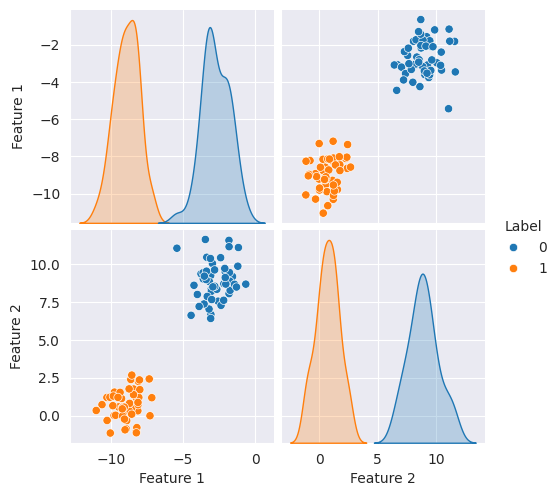

In [3]:

# Visualize first two features for sanity check
df = pd.DataFrame(X[:, :2], columns=["Feature 1", "Feature 2"])
df["Label"] = y

sns.pairplot(df, hue="Label")
plt.show()


In [4]:
# Basic inspection
print(f"Feature vector length: {len(X[0])}")
print(X[0])

print(f"Total samples: {len(y)}")
print(y)

Feature vector length: 300
[ -4.45076542   6.62938062   4.98599617   2.46518396  -4.81540706
  -6.72201472  -8.01858804   7.12805027   2.31952746   5.8287084
 -11.71230293   9.8118133    8.78443955  -5.47118357  -4.71292769
  -6.96112195  -3.94720263   0.52865334  -3.57869071  -5.34359502
   1.14018282  -6.38805671  -3.28495392  -2.34872669  -0.05449742
   5.53936982  -4.80459269   0.29347721   1.90615542  -9.33658438
   2.83534752  -7.01071634  -7.72253676   7.8455616    8.21372441
   6.85537372  -3.99626883  -8.50044914   4.57471826  -1.80421154
  -7.75943656   1.30276615  -7.77308723   9.75880625  -5.10652614
   4.48114859  -4.71473131  -0.50554245  -1.41625027  -4.63004269
   8.52771271   5.37612389   7.87965449   8.59171226   1.58236592
   7.13266781  -7.78848739  -7.51407278  -9.93285995  -5.6002825
  -3.65041232  -4.39449019   4.61021414  -4.34607919  -4.38367872
   0.31031477  -5.18947886   7.87783616  -9.37690959  10.29487635
   6.19417794  -6.62316523 -11.38509919   6.2969301

# Autoencoder Setup

I0000 00:00:1745672627.547524 1255432 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21706 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/50


I0000 00:00:1745672628.193676 1255580 service.cc:152] XLA service 0x742708002e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745672628.193688 1255580 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2025-04-26 06:03:48.202955: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745672628.245377 1255580 cuda_dnn.cc:529] Loaded cuDNN version 90800
2025-04-26 06:03:48.780437: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_88', 52 bytes spill stores, 52 bytes spill loads

2025-04-26 06:03:48.822385: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_265', 12 bytes

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 1.2670

I0000 00:00:1745672629.476122 1255580 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 1.2670 - val_loss: 1.2474
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1.2474 - val_loss: 1.2290
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 1.2290 - val_loss: 1.2108
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1.2108 - val_loss: 1.1922
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.1922 - val_loss: 1.1727
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.1727 - val_loss: 1.1519
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1.1519 - val_loss: 1.1298
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.1298 - val_loss: 1.1063
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.1063 - val_loss: 1.0815
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.0815 - val_loss: 1.0557
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.0557 - val_loss: 1.0291
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.0291 - val_loss: 1.0020
Epoch 13/50
1/

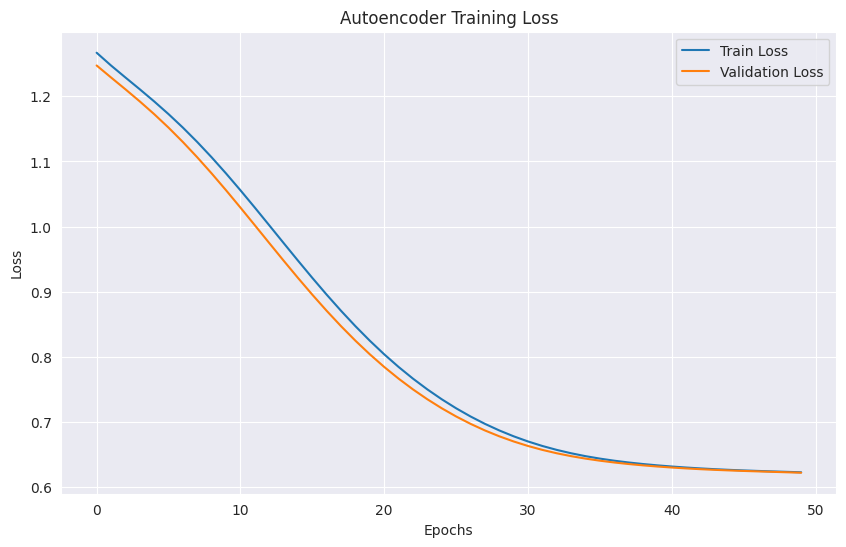

In [5]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Autoencoder architecture
input_dim = X_scaled.shape[1]  # 300 features
encoding_dim = 50  # Latent dimension

input_layer = tf.keras.layers.Input(shape=(input_dim,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_layer)
decoded = tf.keras.layers.Dense(input_dim, activation='sigmoid')(encoded)

# Define models
autoencoder = tf.keras.models.Model(input_layer, decoded)
encoder = tf.keras.models.Model(input_layer, encoded)

# Compile autoencoder
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Train autoencoder
history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(X_scaled, X_scaled)
)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [6]:
# Feature Extraction

# Encode data to lower-dimensional space
pred = encoder.predict(X_scaled)

# Create DataFrame of compressed features
df_pred = pd.DataFrame(pred)
print(df_pred.head())

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
         0         1         2         3         4         5          6   \
0  7.752666  0.000000  5.821512  6.342339  7.089406  0.000000  11.422875   
1  0.000000  7.142170  0.000000  0.000000  0.000000  8.969962   0.000000   
2  8.824385  0.000000  6.787222  5.860000  6.124988  0.000000  10.222331   
3  0.000000  7.727824  0.000000  0.000000  0.000000  8.593699   0.000000   
4  7.866297  0.000000  5.900550  5.042517  7.018088  0.000000  10.958005   

         7          8          9   ...        40         41        42  \
0  0.000000   0.000000  10.955348  ...  0.000000   0.000000  0.000000   
1  9.746516  10.590438   0.000000  ...  7.341274   9.973297  6.173625   
2  0.000000   0.000000   9.905390  ...  0.000000   0.000000  0.000000   
3  9.911862  10.572417   0.000000  ...  8.388254  10.607971  6.438924   
4  0.000000   0.000000  10.066824  ...  0.000000   0.000000  0.000000   

         43         44        45        46         47        48   

In [7]:

# Check basic stats
df_pred.describe()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,4.037417,3.614980,3.210430,2.650367,3.365108,4.347305,5.279803,4.550973,5.353583,4.753284,...,3.618593,4.710565,3.434245,0.825604,5.300654,2.662289,3.988861,5.183605,4.368228,1.177802
std,4.083497,3.666134,3.242268,2.701216,3.409926,4.385023,5.325076,4.598271,5.401652,4.804919,...,3.675094,4.760078,3.483381,0.945767,5.346410,2.715006,4.033997,5.230660,4.414280,1.260748
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.212997,2.836595,2.827036,1.638520,2.825843,3.752047,4.589835,3.776535,4.638763,3.954119,...,2.681230,4.010917,2.728056,0.077233,4.511934,1.984700,3.268679,4.542868,3.636974,0.393924
75%,8.051898,7.196640,6.415538,5.376733,6.683578,8.648345,10.516547,9.091775,10.586858,9.522149,...,7.259632,9.390365,6.812729,1.634716,10.685193,5.300920,8.074889,10.475887,8.769395,2.398418
max,9.923747,8.768630,7.663011,6.371887,8.299054,10.109384,12.071043,10.613307,12.901950,11.150047,...,8.629941,11.095777,8.571841,3.243569,11.955802,6.703953,9.261225,11.890476,10.068373,3.936471


# Feature Variance and Mean Analysis

In [8]:
# Identify low-variance features
variance = df_pred.var()
threshold = 30
low_variance_features = variance[variance < threshold]
print("Low Variance Features:")
print(low_variance_features.sort_values(ascending=False))

# Identify near-zero mean features
mean = df_pred.mean()
zero_mean_features = mean[abs(mean) < threshold]
print("Near-Zero Mean Features:")
print(zero_mean_features)

Low Variance Features:
8     29.177847
24    28.621090
44    28.584101
6     28.356436
14    28.051607
47    27.359810
17    25.012228
9     23.087248
41    22.658348
19    22.467478
37    22.001047
7     21.144094
36    21.090725
34    21.015881
20    20.896723
30    20.365267
48    19.485868
28    19.461885
5     19.228424
22    19.039160
32    18.244596
11    18.133455
16    17.164219
31    17.162054
0     16.674944
12    16.328554
46    16.273130
13    15.380249
25    14.981996
26    14.965661
15    14.849310
18    13.567953
40    13.506316
1     13.440539
33    13.407341
42    12.133945
4     11.627595
2     10.512302
35     9.195674
45     7.371258
3      7.296565
38     5.976002
23     2.850260
10     2.310155
49     1.589486
29     1.423996
43     0.894475
dtype: float32
Near-Zero Mean Features:
0     4.037416
1     3.614980
2     3.210430
3     2.650367
4     3.365107
5     4.347306
6     5.279803
7     4.550973
8     5.353581
9     4.753284
10    1.461686
11    4.214256
12   

# Feature Correlation Analysis

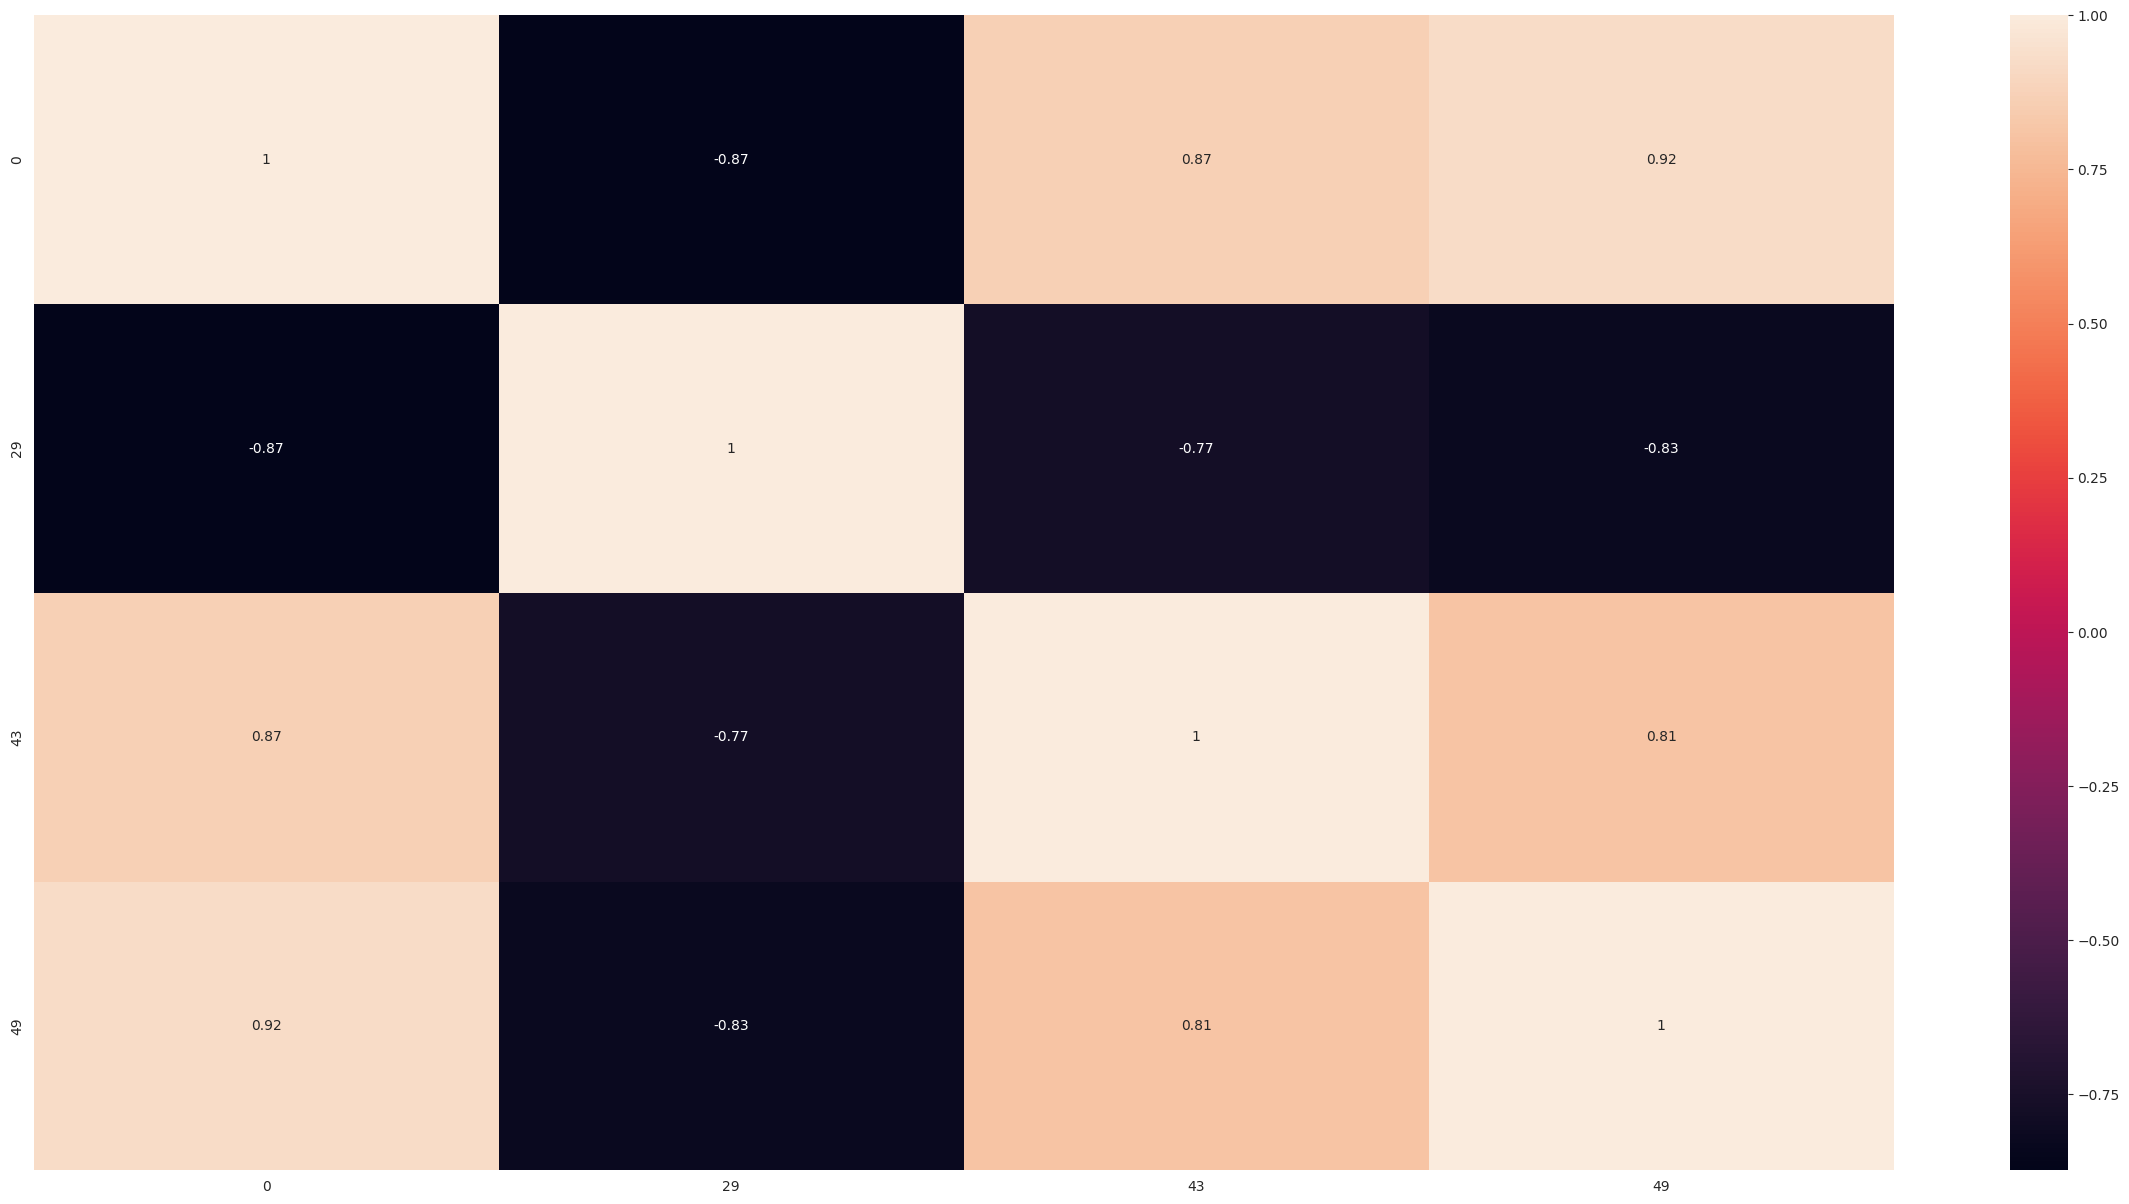

In [9]:
# Calculate feature correlations
correlation_matrix = df_pred.corr()

# Define threshold for high correlation
threshold = 0.95
highly_correlated_pairs = set()

# Detect highly correlated features
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            colname = correlation_matrix.columns[i]
            highly_correlated_pairs.add(colname)

# Drop highly correlated features
df_pred.drop(columns=highly_correlated_pairs, inplace=True)

# Visualize post-pruning correlation heatmap
fig = plt.figure(figsize=(30, 15))
sns.heatmap(df_pred.corr(), annot=True)
plt.show()

# 2D Visualization of Final Features

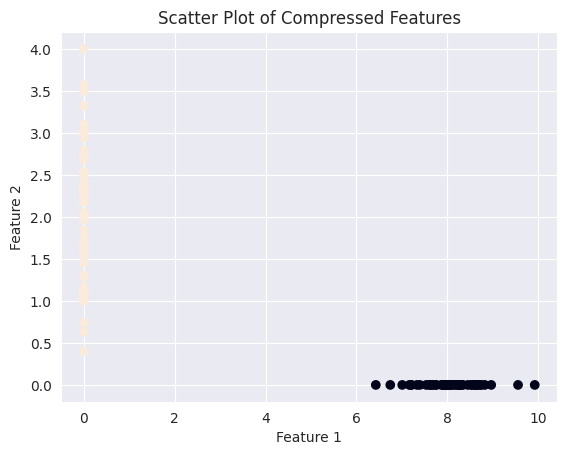

In [10]:
# Scatter plot of first two compressed dimensions
plt.scatter(df_pred.iloc[:, 0], df_pred.iloc[:, 1], c=y)
plt.title('Scatter Plot of Compressed Features')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()